In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
import plotly.figure_factory as ff

In [57]:
# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
# Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, 
# se Y está balanceada no teste.

In [58]:
X_test = pd.read_csv("C:/Users/user/Documents/EBAC/dados/X_test")
X_train = pd.read_csv("C:/Users/user/Documents/EBAC/dados/X_train_balanced")
Y_test = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Y_test")
Y_train = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Y_train_balanced")

In [59]:
num_linhas_X_train = X_train.shape[0]
print("Número de linhas em X_train:", num_linhas_X_train)

num_linhas_X_test = X_test.shape[0]
print("Número de linhas em X_test:", num_linhas_X_test)

Número de linhas em X_train: 252
Número de linhas em X_test: 41


In [60]:
num_linhas_Y_train = Y_train.shape[0]
print("Número de linhas em Y_train:", num_linhas_Y_train)

num_linhas_Y_test = Y_test.shape[0]
print("Número de linhas em Y_test:", num_linhas_Y_test)

Número de linhas em Y_train: 252
Número de linhas em Y_test: 41


In [61]:
# O numero de linhas das etapas de treino e teste estao iguais, como ja se esperava!

In [62]:
X_test.head(5)

,Age,Income,Number of Children,Marital_Status_Encoded,Gender_Encoded,Home_Ownership_Encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25.0,55000.0,0,1,0,1,1,0,0,0
1,48.0,87500.0,1,0,0,0,0,1,0,0
2,26.0,55000.0,1,0,0,0,1,0,0,0
3,39.0,62500.0,2,0,0,0,1,0,0,0
4,35.0,90000.0,1,0,0,0,0,1,0,0


In [63]:
X_train.head(5)

,Age,Income,Number of Children,Marital_Status_Encoded,Gender_Encoded,Home_Ownership_Encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26.0,45000.0,0,1,0,1,0,0,0,0
1,29.0,27500.0,0,1,0,1,0,0,1,0
2,25.0,62500.0,0,1,0,1,1,0,0,0
3,29.0,68000.0,2,0,0,0,0,1,0,0
4,31.0,65000.0,0,1,1,1,1,0,0,0


In [64]:
Y_test.head(5)

,Credit_Score_Encoded
0,0
1,1
2,0
3,1
4,1


In [65]:
Y_train.head(5)

,Credit_Score_Encoded
0,0
1,2
2,0
3,0
4,0


In [66]:
# As variaveis estão corretamente alocadas em X e Y

In [67]:
# Contar o numero de exemplos de cada classe em Y_Train
train_balance = Y_train.value_counts()
print("Balanceamento em Y_train:")
print(train_balance)

# Contar o numero de exemplos de cada classe em Y_test
test_balance = Y_test.value_counts()
print("Balanceamento em Y_test:")
print(test_balance)

Balanceamento em Y_train:
Credit_Score_Encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64
Balanceamento em Y_test:
Credit_Score_Encoded
1                       29
0                        6
2                        6
Name: count, dtype: int64


In [68]:
# OS dados de treino estão balanceados no valor de 84, obedecendo ao principio de que na etapa de treinamento o balanceamento é necessario
# Na etapa de teste, os dados nao estao balanceados e realmente não devem estar, pois, nesta etapa, os dados ja estao treinados e devem ser testados em cenario real

In [69]:
# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [70]:
# Criando uma instância de classificador Naive Bayes Gaussiano
Naive_score = GaussianNB()

#Treinamento de classificador usando os dados de treino
Naive_score.fit(X_train, Y_train)

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



GaussianNB()

In [71]:
# 3) Faça a avaliação do modelo com os dados de treinamento.
# Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

# Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
# recall = recall_score(y_train, y_pred_train, average='macro')

In [76]:
# Fazer previsões para os dados de treino
y_pred_train = Naive_score.predict(X_train)

# Calcular a acurácia
accuracy = accuracy_score(Y_train, y_pred_train)
print('Acurácia:', accuracy)

# Calcular o recall
recall = recall_score(Y_train, y_pred_train, average='macro')
print('recall:', recall)

Acurácia: 0.9841269841269841
recall: 0.9841269841269842


In [77]:
# Acurácia de aproximadamente 0,9841. Um resultado altamente satisfatório, pois o modelo acerta em torno de 98,41% dos casos.

# Um recall de 0.9841 significa que o modelo identificou corretamente aproximadamente 98,41% de todas as instâncias positivas reais.
# Isso também indica um desempenho muito bom do modelo em identificar instâncias positivas.

# Ambas as métricas (acurácia e recall) apresentam valores muito altos, o que sugere que o modelo está tendo um desempenho excelente.

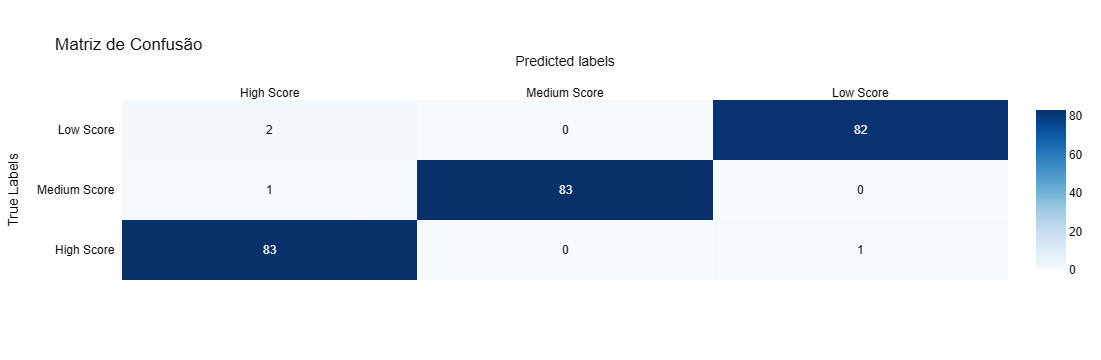

In [53]:
# Matriz de confusão

conf_matrix = confusion_matrix(Y_train, y_pred_train)

# Definindo os nomes de classes
class_names = ['High Score', 'Medium Score', 'Low Score']

# Plotando a matriz de confusão com Ploty
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
	x=class_names,
	y=class_names,
	colorscale='Blues',
	showscale=True
)
fig.update_layout(
	title='Matriz de Confusão',
	xaxis_title='Predicted labels',
	yaxis_title='True Labels',
	font=dict(
		family='Arial',
		size=12,
		color='black'
	)
)

In [54]:
# 1ª linha: 82 acertos como low score
# 2ª linha: 83 acertos como medium score
# 3ª linha: 83 acertos como high score

In [78]:
# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [79]:
# Criando uma instância de classificador Naive Bayes Gaussiano
Naive_score = GaussianNB()

#Treinamento de classificador usando os dados de treino
Naive_score.fit(X_test, Y_test)

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



GaussianNB()

In [80]:
# Fazer previsões para os dados de treino
y_pred_test = Naive_score.predict(X_test)

# Calcular a acurácia
accuracy = accuracy_score(Y_test, y_pred_test)
print('Acurácia:', accuracy)

# Calcular o recall
recall = recall_score(Y_test, y_pred_test, average='macro')
print('recall:', recall)

Acurácia: 1.0
recall: 1.0


In [81]:
# Valores perfeitos de acurácia e teste!!

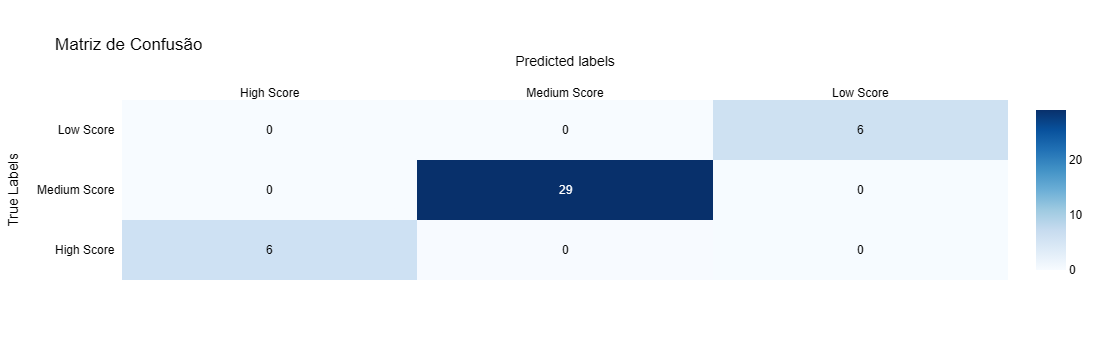

In [82]:
# Matriz de confusão

conf_matrix = confusion_matrix(Y_test, y_pred_test)

# Definindo os nomes de classes
class_names = ['High Score', 'Medium Score', 'Low Score']

# Plotando a matriz de confusão com Ploty
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
	x=class_names,
	y=class_names,
	colorscale='Blues',
	showscale=True
)
fig.update_layout(
	title='Matriz de Confusão',
	xaxis_title='Predicted labels',
	yaxis_title='True Labels',
	font=dict(
		family='Arial',
		size=12,
		color='black'
	)
)

In [83]:
# Como ja esperado apos visualizar o recall e acurácia, vemos na matriz de confusao o nosso modelo agindo perfeitamente na base de testes, sem erro algum!!

In [84]:
# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
# Utilize pelo menos 4 linhas.

# Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

In [85]:
# O Naive bayes é um classificador e, com ele foi possivel treinar este modelo de machine learning para classificar nossos dados de tal maneira
# que possamos criar um modelo de previsao a partir de dados que forneça-nos os perfis congruentes com os clientes que alcancam um alto valor de score
# O Objetivo principal desta atividade creio que, apos a etapa de pre-processamentos dos dados, aplicar os modelos de ML para corroborar com os conhecimentos
# ja obtidos anteriormente e demonstrar como a aplicacao desta tecnica mostra-se ideal para situavcoes como esta!